# Reconocimiento inteligente de modulaciones digitales con DSP e IA

Este notebook resume y justifica el proyecto de investigación. La idea es generar señales IQ sintéticas, aplicar efectos de canal, extraer rasgos de procesamiento digital de señales y entrenar un modelo de IA ligero para clasificar modulaciones digitales.


## Pregunta de investigación

¿Puede un modelo de IA ligero reconocer modulaciones digitales usando rasgos DSP compactos, incluso cuando las señales tienen ruido, fase aleatoria, offset de frecuencia y variación de ganancia?

**Hipótesis:** sí. Los rasgos de amplitud, fase, espectro y constelación conservan suficiente información física para separar modulaciones como BPSK, QPSK, 8PSK, 16QAM, 2FSK y 4ASK.


In [1]:
from pathlib import Path
import csv, json, sys
import numpy as np
try:
    from IPython.display import SVG, display
except Exception:
    class SVG(str):
        pass

    def display(value):
        print(str(value)[:1000])

ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
else:
    # Si se abre desde otra carpeta, ajustar ROOT al directorio del proyecto.
    ROOT = Path("proyecto_dsp_modulaciones").resolve()
    sys.path.insert(0, str(ROOT / "src"))

summary = json.loads((ROOT / "outputs" / "summary.json").read_text(encoding="utf-8"))
print(f"Accuracy entrenamiento: {summary['train_accuracy']*100:.2f}%")
print(f"Accuracy prueba: {summary['test_accuracy']*100:.2f}%")
print("Clases:", ", ".join(summary["clases"]))


Accuracy entrenamiento: 99.44%
Accuracy prueba: 97.92%
Clases: BPSK, QPSK, 8PSK, 16QAM, 2FSK, 4ASK


In [2]:
# SVGs pre-generados para que el notebook sea liviano y no dependa de Matplotlib.
ASSET_DIR = ROOT / "outputs" / "notebook_assets"

def load_svg(name):
    return (ASSET_DIR / name).read_text(encoding="utf-8")

flujo_metodologico_svg = load_svg("flujo_metodologico.svg")
constelaciones_svg = load_svg("constelaciones.svg")
iq_tiempo_svg = load_svg("iq_tiempo.svg")
espectro_svg = load_svg("espectro.svg")
accuracy_por_clase_svg = load_svg("accuracy_por_clase.svg")
matriz_confusion_svg = load_svg("matriz_confusion.svg")


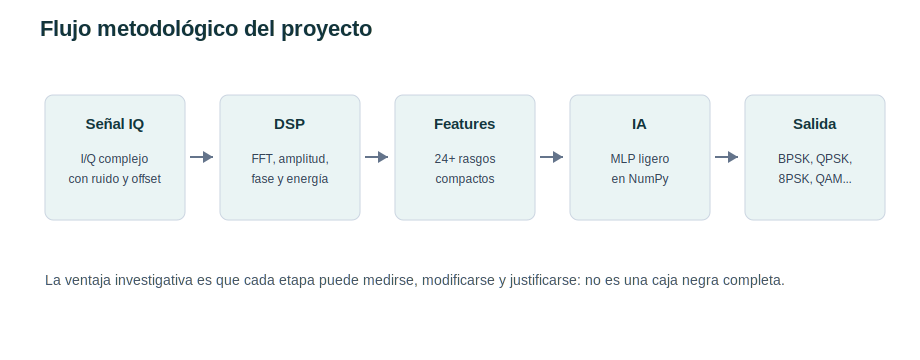

In [3]:
# Flujo conceptual del sistema: de señal IQ a predicción de modulación.
display(SVG(flujo_metodologico_svg))


## Justificación DSP

Las modulaciones digitales no solo se distinguen por el tiempo. También cambian la forma de la constelación, la distribución de fase, el comportamiento espectral y la dinámica de amplitud. Por eso el proyecto extrae rasgos como:

- estadísticos de amplitud I/Q;
- derivadas de fase;
- entropía espectral;
- ancho de banda efectivo;
- relaciones de fase con retardos;
- relación pico/promedio.


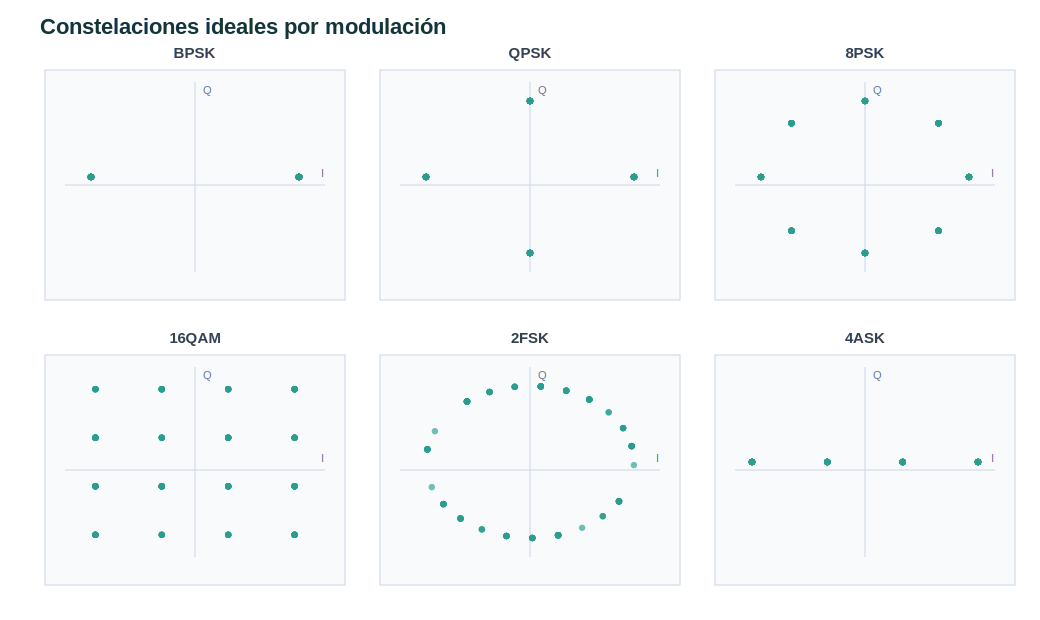

In [4]:
# Las constelaciones muestran por qué el problema es físicamente separable.
display(SVG(constelaciones_svg))


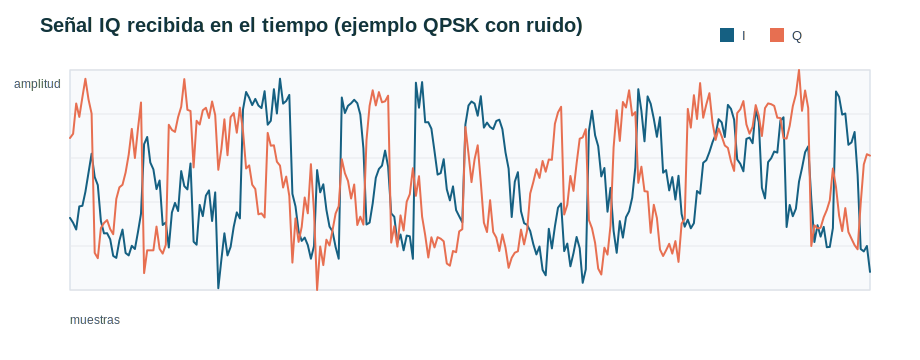

In [5]:
# Ejemplo de señal recibida: componentes I y Q en el dominio del tiempo.
display(SVG(iq_tiempo_svg))


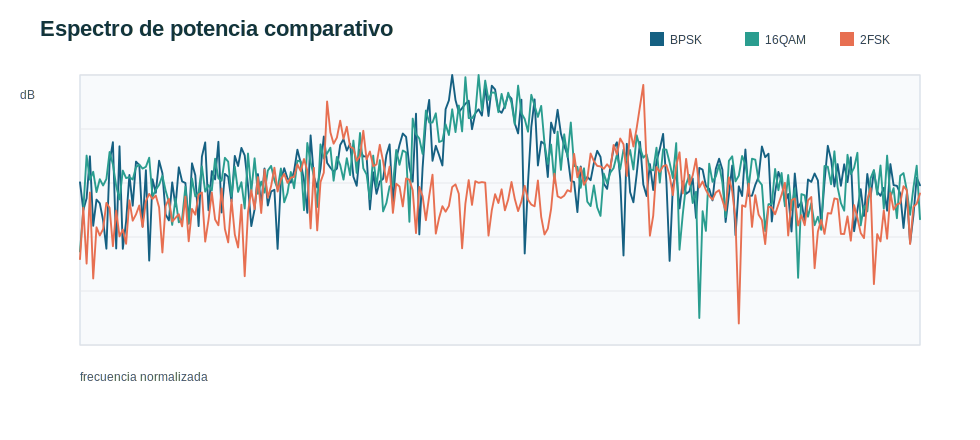

In [6]:
# Comparación espectral: FSK tiende a mostrar concentración en frecuencias separadas.
display(SVG(espectro_svg))


## Justificación del modelo de IA

El modelo usado es una red neuronal MLP implementada en NumPy. Esto hace que el proyecto sea ligero y explicable: no depende de un framework grande, pero sí demuestra aprendizaje supervisado sobre rasgos DSP.

El flujo de entrenamiento es:

1. generar señales sintéticas por clase;
2. aplicar canal con ruido y offset;
3. extraer rasgos DSP;
4. normalizar rasgos;
5. entrenar MLP;
6. evaluar con matriz de confusión.


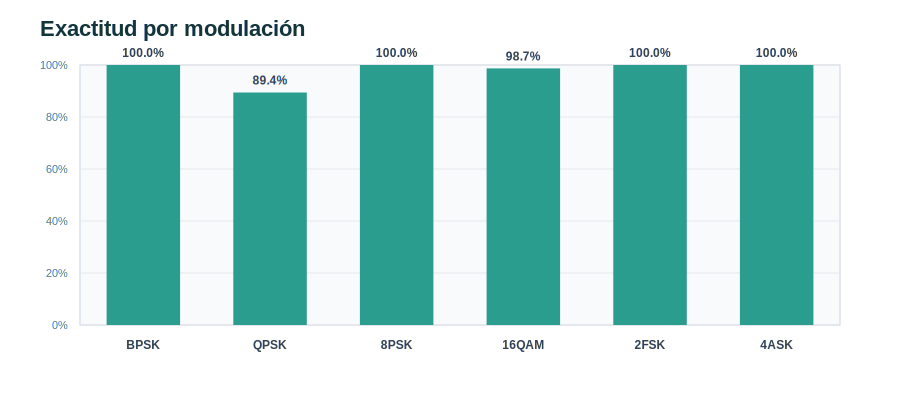

In [7]:
# Accuracy por clase a partir de outputs/summary.json.
display(SVG(accuracy_por_clase_svg))


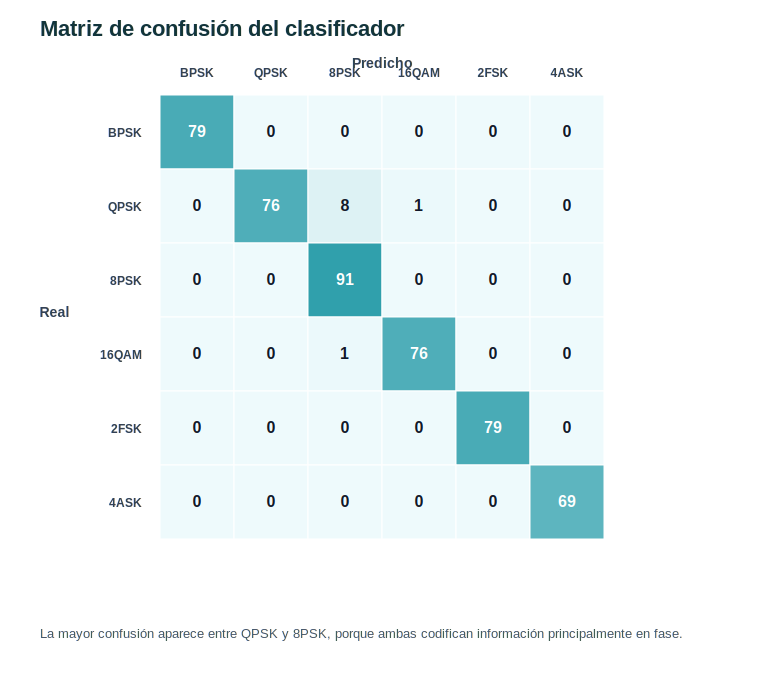

In [8]:
# Matriz de confusión a partir de outputs/confusion_matrix.csv.
display(SVG(matriz_confusion_svg))


## Lectura de resultados

El experimento inicial obtuvo **97.92% de accuracy en prueba**. Las clases BPSK, 8PSK, 2FSK y 4ASK quedaron perfectamente separadas en esta corrida. La mayor confusión aparece entre QPSK y 8PSK, algo razonable porque ambas son modulaciones por fase y pueden parecerse cuando hay ruido u offset.

Esto justifica el proyecto porque combina:

- señales generadas por código;
- fenómenos reales de canal;
- rasgos DSP interpretables;
- un modelo de IA entrenable;
- evaluación cuantitativa.


## Próximas mejoras recomendadas

- Evaluar accuracy por niveles de SNR: 0 dB, 5 dB, 10 dB, 15 dB, 20 dB.
- Agregar canal Rayleigh o multipath.
- Comparar contra un clasificador basado en reglas.
- Convertir señales a espectrogramas y probar una CNN.
- Crear una interfaz que muestre señal, FFT, constelación y predicción.
